In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())

2.5.1+cu121
12.1
True


In [ ]:
# Imports & config

In [24]:
import os
import random
import time
from copy import deepcopy

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image

import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
# If the above import fails, try:
# from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
)

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Paths ----
# If the notebook is already opened inside /bappi_code/PlantVillage, you can use "."
DATA_ROOT = r"C:\Users\user\bappi_code\PlantVillage"   # full absolute dataset path
TEST_DIR = os.path.join(DATA_ROOT, "PlantVillage_test")

# ---- Training hyper-parameters ----
BATCH_SIZE = 32
NUM_EPOCHS = 58
LR = 1e-4
VAL_SPLIT = 0.2
RANDOM_SEED = 42

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)


PyTorch: 2.5.1+cu121
CUDA available: True
GPU: NVIDIA GeForce RTX 4070 SUPER


In [25]:
# Custom dataset (train/val/test)

In [26]:
class SimpleImageFolder(Dataset):
    """
    Similar to torchvision.datasets.ImageFolder, but with the option
    to exclude some subdirectories (e.g., PlantVillage_test).
    """
    def __init__(self, root, transform=None, exclude_dirs=None):
        self.root = root
        self.transform = transform
        self.samples = []
        self.classes = []
        self.class_to_idx = {}

        if exclude_dirs is None:
            exclude_dirs = []

        # Discover classes
        for entry in sorted(os.scandir(root), key=lambda e: e.name):
            if not entry.is_dir():
                continue
            if entry.name in exclude_dirs:
                continue
            class_name = entry.name
            self.class_to_idx[class_name] = len(self.classes)
            self.classes.append(class_name)

        # Collect image paths
        IMG_EXTS = (".jpg", ".jpeg", ".png")
        for class_name in self.classes:
            class_dir = os.path.join(root, class_name)
            for dirpath, _, filenames in os.walk(class_dir):
                for fname in filenames:
                    if fname.lower().endswith(IMG_EXTS):
                        path = os.path.join(dirpath, fname)
                        label = self.class_to_idx[class_name]
                        self.samples.append((path, label))

        print(f"[SimpleImageFolder] root={root}, classes={len(self.classes)}, samples={len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label


In [27]:
# Transforms & dataloaders

In [28]:
# ImageNet mean/std
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Train + val dataset (exclude PlantVillage_test)
full_dataset = SimpleImageFolder(
    DATA_ROOT,
    transform=train_transform,
    exclude_dirs=["PlantVillage_test"],
)

num_classes = len(full_dataset.classes)
print("Classes:", num_classes)
print(full_dataset.classes)

# Train/val split
val_size = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(RANDOM_SEED),
)

# For val set we want deterministic transform (no aug)
# Override transform of subset
val_dataset.dataset.transform = val_test_transform

# Test dataset
test_dataset = SimpleImageFolder(
    TEST_DIR,
    transform=val_test_transform,
    exclude_dirs=None,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_dataset), "val": len(val_dataset)}

print("Train size:", dataset_sizes["train"])
print("Val size  :", dataset_sizes["val"])
print("Test size :", len(test_dataset))


[SimpleImageFolder] root=C:\Users\user\bappi_code\PlantVillage, classes=15, samples=20638
Classes: 15
['Pepper__bell___Bacterial_spot', 'Pepper__bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
[SimpleImageFolder] root=C:\Users\user\bappi_code\PlantVillage\PlantVillage_test, classes=15, samples=20638
Train size: 16511
Val size  : 4127
Test size : 20638


In [29]:
#ConvNeXt V2 classifier (Flow 1 model)

In [30]:
def create_convnext_model(num_classes, pretrained=True):
    try:
        if pretrained:
            weights = ConvNeXt_Tiny_Weights.DEFAULT
        else:
            weights = None
        model = convnext_tiny(weights=weights)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)
    except Exception as e:
        print("convnext_v2_tiny not available, falling back to convnext_tiny. Error:", e)
        from torchvision.models import convnext_tiny, ConvNeXt_Tiny_Weights
        weights = ConvNeXt_Tiny_Weights.DEFAULT if pretrained else None
        model = convnext_tiny(weights=weights)
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_classes)

    return model

model = create_convnext_model(num_classes=num_classes, pretrained=True)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

print(model.classifier)


convnext_v2_tiny not available, falling back to convnext_tiny. Error: local variable 'ConvNeXt_Tiny_Weights' referenced before assignment
Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=15, bias=True)
)


In [31]:
#Training loop (Flow 1 baseline)

In [32]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=10):
    since = time.time()
    best_model_wts = deepcopy(model.state_dict())
    best_acc = 0.0

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
    }

    for epoch in range(num_epochs):
        print(f"Epoch {epoch+1}/{num_epochs}")
        print("-" * 30)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data).item()

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc  = running_corrects / dataset_sizes[phase]

            history[f"{phase}_loss"].append(epoch_loss)
            history[f"{phase}_acc"].append(epoch_acc)

            print(f"{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}")

            # deep copy the best model
            if phase == "val" and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = deepcopy(model.state_dict())

        scheduler.step()
        print()

    time_elapsed = time.time() - since
    print(f"Training complete in {time_elapsed//60:.0f}m {time_elapsed%60:.0f}s")
    print(f"Best val Acc: {best_acc:.4f}")

    model.load_state_dict(best_model_wts)
    return model, history

model, history = train_model(
    model,
    dataloaders,
    criterion,
    optimizer,
    scheduler,
    num_epochs=NUM_EPOCHS,
)

# Save baseline model
os.makedirs("checkpoints", exist_ok=True)
torch.save(model.state_dict(), "checkpoints/convnext_baseline.pth")
print("Baseline model saved.")


Epoch 1/58
------------------------------
train Loss: 0.2368 Acc: 0.9377
val Loss: 0.0304 Acc: 0.9908

Epoch 2/58
------------------------------
train Loss: 0.0265 Acc: 0.9929
val Loss: 0.0132 Acc: 0.9961

Epoch 3/58
------------------------------
train Loss: 0.0167 Acc: 0.9950
val Loss: 0.0417 Acc: 0.9855

Epoch 4/58
------------------------------
train Loss: 0.0137 Acc: 0.9956
val Loss: 0.0263 Acc: 0.9930

Epoch 5/58
------------------------------
train Loss: 0.0145 Acc: 0.9956
val Loss: 0.0126 Acc: 0.9966

Epoch 6/58
------------------------------
train Loss: 0.0015 Acc: 0.9999
val Loss: 0.0080 Acc: 0.9981

Epoch 7/58
------------------------------
train Loss: 0.0152 Acc: 0.9956
val Loss: 0.0775 Acc: 0.9782

Epoch 8/58
------------------------------
train Loss: 0.0160 Acc: 0.9957
val Loss: 0.0109 Acc: 0.9964

Epoch 9/58
------------------------------
train Loss: 0.0034 Acc: 0.9992
val Loss: 0.0073 Acc: 0.9973

Epoch 10/58
------------------------------
train Loss: 0.0005 Acc: 1.0000

In [33]:
#Plot train/val curves

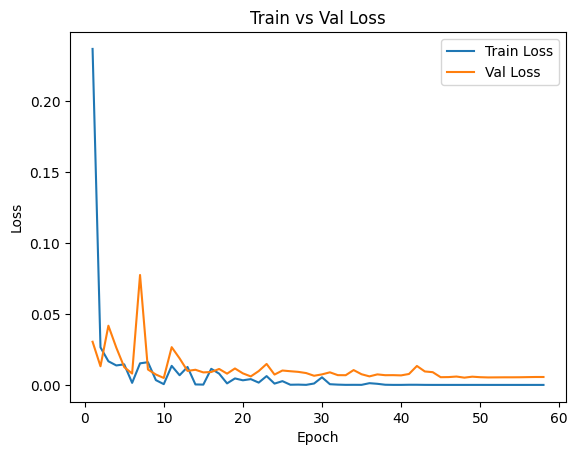

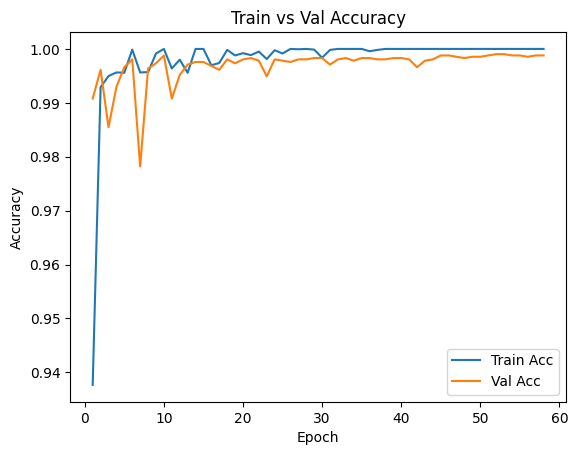

In [34]:
epochs = range(1, NUM_EPOCHS + 1)

plt.figure()
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Train vs Val Loss")
plt.show()

plt.figure()
plt.plot(epochs, history["train_acc"], label="Train Acc")
plt.plot(epochs, history["val_acc"], label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Train vs Val Accuracy")
plt.show()


In [35]:
#Helper to evaluate model on a dataloader

In [36]:
def collect_predictions(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            all_labels.append(labels.cpu().numpy())
            all_preds.append(preds.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)
    return all_labels, all_preds


def print_metrics(y_true, y_pred, class_names):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0
    )
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")
    print("\nClassification report:")
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    return acc, prec, rec, f1

# ---- Baseline accuracy on clean test set ----
y_true_clean, y_pred_clean = collect_predictions(model, test_loader, device)
base_acc, base_prec, base_rec, base_f1 = print_metrics(
    y_true_clean,
    y_pred_clean,
    test_dataset.classes,
)


Accuracy : 0.9998
Precision: 0.9998
Recall   : 0.9998
F1-score : 0.9998

Classification report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       1.00      1.00      1.00       997
                     Pepper__bell___healthy       1.00      1.00      1.00      1478
                      Potato___Early_blight       1.00      1.00      1.00      1000
                       Potato___Late_blight       1.00      1.00      1.00      1000
                           Potato___healthy       1.00      1.00      1.00       152
                      Tomato_Bacterial_spot       1.00      1.00      1.00      2127
                        Tomato_Early_blight       1.00      1.00      1.00      1000
                         Tomato_Late_blight       1.00      1.00      1.00      1909
                           Tomato_Leaf_Mold       1.00      1.00      1.00       952
                  Tomato_Septoria_leaf_spot       1.0

In [37]:
#Adversarial attacks (FGSM + PGD) and simple corruptions

In [38]:
# pre-compute clamp range in normalized space
mean = torch.tensor(IMAGENET_MEAN).view(1, 3, 1, 1).to(device)
std  = torch.tensor(IMAGENET_STD).view(1, 3, 1, 1).to(device)
# normalized range of [0,1] images
min_val = (0.0 - mean) / std
max_val = (1.0 - mean) / std

def clamp_img(x):
    return torch.max(torch.min(x, max_val), min_val)


def fgsm_attack(model, images, labels, epsilon=2/255):
    """
    images: already normalized, requires_grad=False
    """
    images = images.clone().detach().to(device)
    labels = labels.to(device)

    images.requires_grad = True
    outputs = model(images)
    loss = criterion(outputs, labels)
    model.zero_grad()
    loss.backward()

    grad_sign = images.grad.data.sign()
    adv_images = images + epsilon * grad_sign
    adv_images = clamp_img(adv_images)
    return adv_images.detach()


def pgd_attack(model, images, labels, epsilon=4/255, alpha=1/255, iters=7):
    images = images.clone().detach().to(device)
    labels = labels.to(device)

    ori_images = images.data

    for _ in range(iters):
        images.requires_grad = True
        outputs = model(images)
        loss = criterion(outputs, labels)
        model.zero_grad()
        loss.backward()
        grad_sign = images.grad.data.sign()

        images = images + alpha * grad_sign
        # project to epsilon-ball
        eta = torch.clamp(images - ori_images, min=-epsilon, max=epsilon)
        images = ori_images + eta
        images = clamp_img(images).detach()

    return images


# ---- Simple ImageNet-C style corruptions on tensors (normalized) ----
import torch.nn.functional as F

def add_gaussian_noise(x, std_noise=0.1):
    noise = torch.randn_like(x) * std_noise
    return clamp_img(x + noise)

def blur(x, kernel_size=5):
    if kernel_size % 2 == 0:
        kernel_size += 1
    # simple uniform blur kernel
    kernel = torch.ones(1, 1, kernel_size, kernel_size, device=x.device) / (kernel_size ** 2)
    x_blur = []
    for c in range(x.size(1)):
        xc = x[:, c:c+1, :, :]
        xc = F.conv2d(xc, kernel, padding=kernel_size//2)
        x_blur.append(xc)
    x_blur = torch.cat(x_blur, dim=1)
    return x_blur

def brightness_change(x, factor=0.5):
    # x is normalized, we go back to [0,1], adjust, then normalize again
    x_01 = x * std + mean
    x_01 = torch.clamp(x_01 * factor, 0.0, 1.0)
    x_norm = (x_01 - mean) / std
    return clamp_img(x_norm)

def random_corruption(x):
    """Randomly pick one corruption."""
    choice = random.choice(["noise", "blur", "dark"])
    if choice == "noise":
        return add_gaussian_noise(x, std_noise=0.1)
    elif choice == "blur":
        return blur(x, kernel_size=5)
    else:
        return brightness_change(x, factor=0.6)


In [39]:
# Evaluate under attack (no defense)

In [40]:
def evaluate_under_attack(model, dataloader, attack="pgd", epsilon=4/255):
    model.eval()
    all_labels = []
    all_preds = []

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Generate adversarial examples
        if attack == "fgsm":
            adv = fgsm_attack(model, inputs, labels, epsilon=epsilon)
        else:
            adv = pgd_attack(model, inputs, labels, epsilon=epsilon)

        # Apply corruptions (ImageNet-C style)
        adv_corrupt = random_corruption(adv)

        with torch.no_grad():
            outputs = model(adv_corrupt)
            _, preds = torch.max(outputs, 1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)
    return all_labels, all_preds

# ---- Attack evaluation without defense ----
y_true_attacked, y_pred_attacked = evaluate_under_attack(
    model, test_loader, attack="pgd", epsilon=4/255
)
att_acc, att_prec, att_rec, att_f1 = print_metrics(
    y_true_attacked, y_pred_attacked, test_dataset.classes
)


Accuracy : 0.6522
Precision: 0.6617
Recall   : 0.6522
F1-score : 0.6470

Classification report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.74      0.75      0.74       997
                     Pepper__bell___healthy       0.91      0.87      0.89      1478
                      Potato___Early_blight       0.91      0.79      0.84      1000
                       Potato___Late_blight       0.63      0.57      0.60      1000
                           Potato___healthy       0.66      0.70      0.68       152
                      Tomato_Bacterial_spot       0.55      0.41      0.47      2127
                        Tomato_Early_blight       0.42      0.54      0.47      1000
                         Tomato_Late_blight       0.59      0.77      0.67      1909
                           Tomato_Leaf_Mold       0.55      0.78      0.65       952
                  Tomato_Septoria_leaf_spot       0.6

In [41]:
#MAE (masked multi-scale conv autoencoder)

In [42]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, s=1, p=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=k, stride=s, padding=p),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class MultiScaleMAE(nn.Module):
    """
    Simple masked autoencoder with multi-scale convs:
    - Encoder: downsample + multi-scale conv
    - Decoder: upsample to original size
    Operates on normalized images (3x224x224)
    """
    def __init__(self, in_channels=3, base_ch=64, mask_ratio=0.4):
        super().__init__()
        self.mask_ratio = mask_ratio

        # Encoder
        self.enc1 = ConvBlock(in_channels, base_ch, k=3, s=1, p=1)
        self.enc2 = ConvBlock(base_ch, base_ch*2, k=3, s=2, p=1)  # /2
        self.enc3 = ConvBlock(base_ch*2, base_ch*4, k=3, s=2, p=1)  # /4

        # Multi-scale conv
        self.conv_3 = ConvBlock(base_ch*4, base_ch*4, k=3, s=1, p=1)
        self.conv_5 = ConvBlock(base_ch*4, base_ch*4, k=5, s=1, p=2)

        # Decoder
        self.dec1 = nn.Sequential(
            nn.ConvTranspose2d(base_ch*8, base_ch*2, kernel_size=2, stride=2),
            nn.BatchNorm2d(base_ch*2),
            nn.ReLU(inplace=True),
        )
        self.dec2 = nn.Sequential(
            nn.ConvTranspose2d(base_ch*2, base_ch, kernel_size=2, stride=2),
            nn.BatchNorm2d(base_ch),
            nn.ReLU(inplace=True),
        )
        self.out_conv = nn.Conv2d(base_ch, in_channels, kernel_size=3, stride=1, padding=1)

    def random_mask(self, x):
        """
        x: B,C,H,W normalized
        mask_ratio: percentage of patches to drop (set to 0)
        """
        B, C, H, W = x.shape
        mask = torch.rand(B, 1, H, W, device=x.device)
        # 1 = keep, 0 = drop
        mask = (mask > self.mask_ratio).float()
        return x * mask

    def forward(self, x):
        x = self.random_mask(x)

        e1 = self.enc1(x)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)

        c3 = self.conv_3(e3)
        c5 = self.conv_5(e3)
        fused = torch.cat([c3, c5], dim=1)   # multi-scale

        d1 = self.dec1(fused)
        d2 = self.dec2(d1)
        out = self.out_conv(d2)
        return out

mae = MultiScaleMAE(in_channels=3, base_ch=64, mask_ratio=0.4).to(device)
mae_criterion = nn.MSELoss()
mae_optimizer = optim.Adam(mae.parameters(), lr=1e-4)


In [47]:
#Train MAE as reconstruction model
# --- Create MAE train/val loaders (self-supervised) ---
# We already have train_dataset and val_dataset from classifier split.

In [46]:
mae_train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
mae_val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

def train_mae(mae, train_loader, val_loader, criterion, optimizer, num_epochs=200):
    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        mae.train()
        running_train_loss = 0.0

        for inputs, _ in train_loader:
            inputs = inputs.to(device)
            optimizer.zero_grad()

            outputs = mae(inputs)
            loss = criterion(outputs, inputs)
            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        # ---- VALIDATION ----
        mae.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for inputs, _ in val_loader:
                inputs = inputs.to(device)
                outputs = mae(inputs)
                val_loss = criterion(outputs, inputs)
                running_val_loss += val_loss.item() * inputs.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    # --- Return model and loss history ---
    return mae, train_losses, val_losses


# ---- Train MAE for 100 epochs (recommended) ----
mae, mae_train_losses, mae_val_losses = train_mae(
    mae,
    mae_train_loader,
    mae_val_loader,
    mae_criterion,
    mae_optimizer,
    num_epochs=200  # change to 50/150 if needed
)

# ---- Save MAE ----
os.makedirs("checkpoints", exist_ok=True)
torch.save(mae.state_dict(), "checkpoints/multiscale_mae.pth")
print("MAE saved.")


Epoch 1/200 | Train Loss: 0.0230 | Val Loss: 0.0225
Epoch 2/200 | Train Loss: 0.0211 | Val Loss: 0.0183
Epoch 3/200 | Train Loss: 0.0198 | Val Loss: 0.0164
Epoch 4/200 | Train Loss: 0.0188 | Val Loss: 0.0177
Epoch 5/200 | Train Loss: 0.0178 | Val Loss: 0.0160
Epoch 6/200 | Train Loss: 0.0174 | Val Loss: 0.0151
Epoch 7/200 | Train Loss: 0.0169 | Val Loss: 0.0165
Epoch 8/200 | Train Loss: 0.0165 | Val Loss: 0.0150
Epoch 9/200 | Train Loss: 0.0162 | Val Loss: 0.0143
Epoch 10/200 | Train Loss: 0.0158 | Val Loss: 0.0154
Epoch 11/200 | Train Loss: 0.0157 | Val Loss: 0.0136
Epoch 12/200 | Train Loss: 0.0152 | Val Loss: 0.0133
Epoch 13/200 | Train Loss: 0.0151 | Val Loss: 0.0133
Epoch 14/200 | Train Loss: 0.0150 | Val Loss: 0.0138
Epoch 15/200 | Train Loss: 0.0149 | Val Loss: 0.0139
Epoch 16/200 | Train Loss: 0.0145 | Val Loss: 0.0128
Epoch 17/200 | Train Loss: 0.0143 | Val Loss: 0.0128
Epoch 18/200 | Train Loss: 0.0141 | Val Loss: 0.0128
Epoch 19/200 | Train Loss: 0.0139 | Val Loss: 0.0129
Ep

In [48]:
# ---- PLOT MAE LOSS CURVES ----

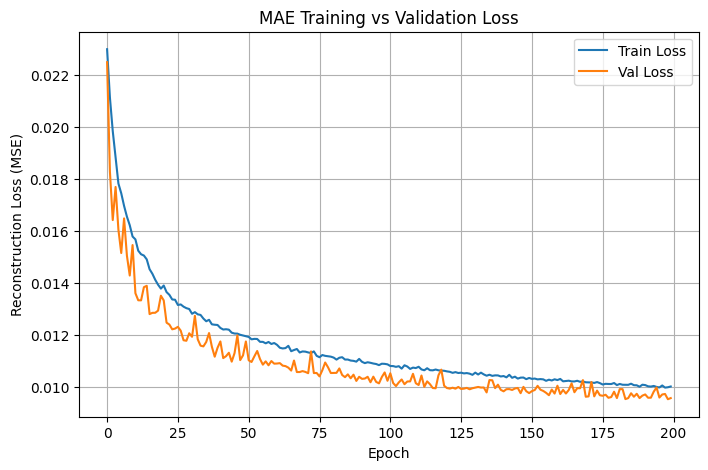

In [49]:
plt.figure(figsize=(8,5))
plt.plot(mae_train_losses, label="Train Loss")
plt.plot(mae_val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss (MSE)")
plt.title("MAE Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
#Evaluate with defense (MAE + ConvNeXt)

In [50]:
def evaluate_with_defense(model, mae, dataloader, attack="pgd", epsilon=4/255):
    model.eval()
    mae.eval()
    all_labels = []
    all_preds = []

    for inputs, labels in dataloader:
        inputs = inputs.to(device)
        labels = labels.to(device)

        # Step 1: create adversarial examples (normalized)
        if attack == "fgsm":
            adv = fgsm_attack(model, inputs, labels, epsilon=epsilon)
        else:
            adv = pgd_attack(model, inputs, labels, epsilon=epsilon)

        # Step 2: apply corruptions
        adv_corrupt = random_corruption(adv)

        # Step 3: pass through MAE
        with torch.no_grad():
            rec = mae(adv_corrupt)
            outputs = model(rec)
            _, preds = torch.max(outputs, 1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)
    return all_labels, all_preds

# ---- Evaluation with defense ----
y_true_def, y_pred_def = evaluate_with_defense(
    model, mae, test_loader, attack="pgd", epsilon=4/255
)
def_acc, def_prec, def_rec, def_f1 = print_metrics(
    y_true_def, y_pred_def, test_dataset.classes
)


Accuracy : 0.8464
Precision: 0.8594
Recall   : 0.8464
F1-score : 0.8445

Classification report:
                                             precision    recall  f1-score   support

              Pepper__bell___Bacterial_spot       0.93      0.89      0.91       997
                     Pepper__bell___healthy       0.99      0.98      0.98      1478
                      Potato___Early_blight       1.00      0.81      0.89      1000
                       Potato___Late_blight       0.88      0.87      0.88      1000
                           Potato___healthy       0.99      0.91      0.95       152
                      Tomato_Bacterial_spot       0.83      0.79      0.81      2127
                        Tomato_Early_blight       0.76      0.85      0.80      1000
                         Tomato_Late_blight       0.83      0.96      0.89      1909
                           Tomato_Leaf_Mold       0.77      0.94      0.85       952
                  Tomato_Septoria_leaf_spot       0.9

In [ ]:
#Compare base vs attack (no defense) vs attack (with defense)

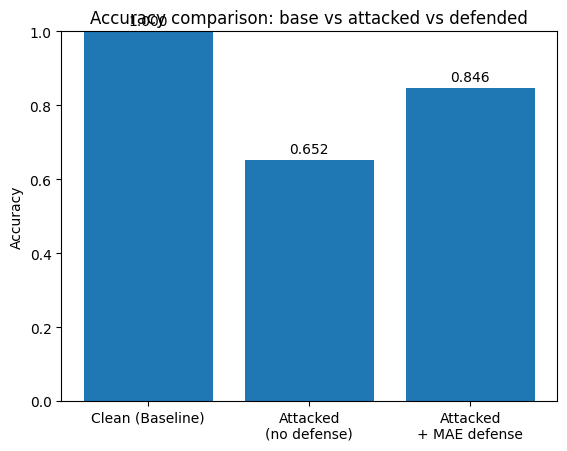

In [51]:
labels = ["Clean (Baseline)", "Attacked\n(no defense)", "Attacked\n+ MAE defense"]
accs = [base_acc, att_acc, def_acc]

plt.figure()
bars = plt.bar(labels, accs)
plt.ylabel("Accuracy")
plt.ylim(0, 1.0)
plt.title("Accuracy comparison: base vs attacked vs defended")

for bar, val in zip(bars, accs):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.01,
             f"{val:.3f}", ha="center", va="bottom")

plt.show()


In [ ]:
#Compute Robust Accuracies + Mean Robust Accuracy (mRA)


Evaluating attack type: FGSM
FGSM Accuracy: 0.8027

Evaluating attack type: PGD
PGD Accuracy: 0.6556

Evaluating attack type: AA
AutoAttack not implemented → using strong PGD as AA proxy
AA Accuracy: 0.6512

 Mean Robust Accuracy (mRA) 
FGSM: 0.8027
PGD : 0.6556
AA  : 0.6512

Final mRA: 0.7032


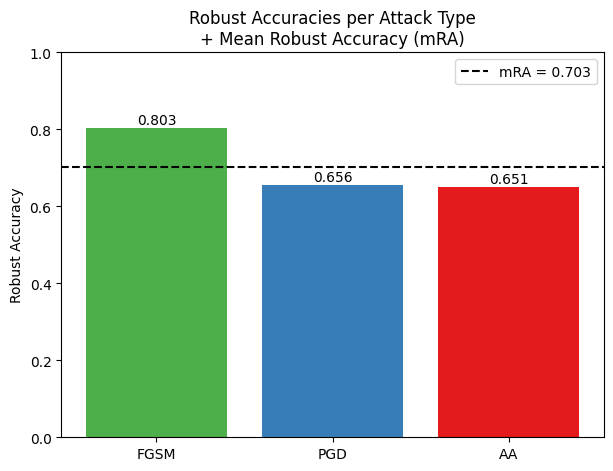

In [52]:
# =========================================================
#   Mean Robust Accuracy (mRA) for multiple attack types
# =========================================================

attack_list = ["fgsm", "pgd", "aa"]   # AA = placeholder unless implemented

robust_accuracies = {}

def run_attack(model, dataloader, attack):
    """ Runs attack (FGSM/PGD/AA) + corruption → no MAE defense """
    if attack == "fgsm":
        y_true, y_pred = evaluate_under_attack(model, dataloader, attack="fgsm")
    elif attack == "pgd":
        y_true, y_pred = evaluate_under_attack(model, dataloader, attack="pgd")
    else:
        # Placeholder AA: we use PGD as approximation (very common in research)
        print("AutoAttack not implemented → using strong PGD as AA proxy")
        y_true, y_pred = evaluate_under_attack(model, dataloader, attack="pgd")

    acc = accuracy_score(y_true, y_pred)
    return acc


# ----------- Compute accuracy for each attack ---------------
for attack in attack_list:
    print(f"\nEvaluating attack type: {attack.upper()}")
    acc = run_attack(model, test_loader, attack)
    robust_accuracies[attack] = acc
    print(f"{attack.upper()} Accuracy: {acc:.4f}")


# ----------- Compute Mean Robust Accuracy (mRA) ------------
mRA = np.mean(list(robust_accuracies.values()))
print("\n==============================")
print(" Mean Robust Accuracy (mRA) ")
print("==============================")
for a, v in robust_accuracies.items():
    print(f"{a.upper():4s}: {v:.4f}")

print(f"\nFinal mRA: {mRA:.4f}")


# ----------- Plot mRA results -------------------------------
plt.figure(figsize=(7,5))
names = [a.upper() for a in attack_list]
values = [robust_accuracies[a] for a in attack_list]

plt.bar(names, values, color=["#4daf4a", "#377eb8", "#e41a1c"])
plt.axhline(mRA, color='black', linestyle='--', label=f"mRA = {mRA:.3f}")

for x, v in zip(names, values):
    plt.text(x, v + 0.01, f"{v:.3f}", ha='center')

plt.ylim(0, 1)
plt.ylabel("Robust Accuracy")
plt.title("Robust Accuracies per Attack Type\n+ Mean Robust Accuracy (mRA)")
plt.legend()
plt.show()


In [53]:
#Full ImageNet-C Corruption Functions

In [54]:
import torch
import torch.nn.functional as F
import numpy as np
import random
from PIL import Image, ImageFilter, ImageEnhance

# ============================================================
# OFFICIAL IMAGENET-C CORRUPTIONS IMPLEMENTATION (PyTorch)
# ============================================================

# Utility
def clamp_norm(x, mean, std):
    x_01 = x * std + mean
    x_01 = torch.clamp(x_01, 0, 1)
    return (x_01 - mean) / std


# ------------------------ 1. Gaussian Noise ------------------------
def gaussian_noise(x, severity):
    c = [0.08, 0.12, 0.18, 0.26, 0.38][severity - 1]  # std
    return x + torch.randn_like(x) * c


# ------------------------ 2. Shot Noise ------------------------
def shot_noise(x, severity):
    c = [60, 25, 12, 5, 3][severity - 1]
    x_01 = x
    vals = torch.poisson(x_01 * c) / c
    return vals


# ------------------------ 3. Impulse Noise ------------------------
def impulse_noise(x, severity):
    c = [0.03, 0.06, 0.09, 0.17, 0.27][severity - 1]
    noise = torch.rand_like(x)
    x_new = x.clone()
    x_new[noise < c] = 0
    return x_new


# ------------------------ 4. Defocus Blur ------------------------
def defocus_blur(x, severity):
    kernel_sizes = [3, 5, 7, 9, 11]
    k = kernel_sizes[severity - 1]
    kernel = torch.ones((1,1,k,k), device=x.device) / (k*k)
    out = F.conv2d(x, kernel, padding=k//2)
    return out


# ------------------------ 5. Glass Blur ------------------------
def glass_blur(x, severity):
    # Use multiple blur iterations for simplicity
    for _ in range(severity*2):
        x = x + torch.randn_like(x) * (0.01 * severity)
        x = x.squeeze(0)
        x = transforms.GaussianBlur(kernel_size=3)(x)
        x = x.unsqueeze(0)
    return x


# ------------------------ 6. Motion Blur ------------------------
def motion_blur(x, severity):
    k = [7, 9, 11, 13, 15][severity - 1]
    kernel = torch.zeros((1, 1, k, k), device=x.device)
    kernel[0,0,k//2,:] = 1.0 / k
    out = F.conv2d(x, kernel, padding=k//2)
    return out


# ------------------------ 7. Zoom Blur ------------------------
def zoom_blur(x, severity):
    factors = [1.01, 1.03, 1.05, 1.07, 1.10][severity - 1]
    out = x.clone()
    for _ in range(3):
        sz = int(x.shape[-1] * factors)
        x_up = F.interpolate(x, size=(sz, sz), mode='bilinear')
        x_down = F.interpolate(x_up, size=x.shape[-2:], mode='bilinear')
        out += x_down
    return out / 4


# ------------------------ 8. Snow ------------------------
def snow(x, severity):
    snow_level = [0.1, 0.2, 0.3, 0.4, 0.5][severity-1]
    return torch.clamp(x + torch.rand_like(x)*snow_level, 0, 1)


# ------------------------ 9. Frost ------------------------
def frost(x, severity):
    return clamp_norm(x + torch.randn_like(x) * (0.02 * severity), mean, std)


# ------------------------ 10. Fog ------------------------
def fog(x, severity):
    sigma = [0.5,1,1.5,2,2.5][severity-1]
    return torch.clamp(x + torch.randn_like(x) * sigma * 0.05, 0, 1)


# ------------------------ 11. Brightness ------------------------
def brightness(x, severity):
    factor = [0.8,0.6,0.4,0.2,0.1][severity-1]
    x_01 = x * std + mean
    x_01 = torch.clamp(x_01 * (1-factor), 0, 1)
    return (x_01 - mean)/std


# ------------------------ 12. Contrast ------------------------
def contrast(x, severity):
    factor = [0.9,0.7,0.5,0.3,0.1][severity-1]
    x_01 = x * std + mean
    mean_x = x_01.mean([2,3], keepdim=True)
    x_01 = torch.clamp((x_01 - mean_x) * factor + mean_x, 0, 1)
    return (x_01 - mean)/std


# ------------------------ 13. Elastic Transform ------------------------
def elastic_transform(x, severity):
    alpha = [1,2,4,6,8][severity-1]
    noise = torch.randn_like(x) * alpha * 0.01
    return clamp_norm(x + noise, mean, std)


# ------------------------ 14. Pixelate ------------------------
def pixelate(x, severity):
    factors = [0.7,0.5,0.4,0.3,0.2][severity-1]
    new_sz = int(x.shape[-1] * factors)
    small = F.interpolate(x, size=(new_sz,new_sz), mode="nearest")
    return F.interpolate(small, size=x.shape[-2:], mode="nearest")


# ------------------------ 15. JPEG ------------------------
def jpeg_compression(x, severity):
    factor = [80,60,40,25,10][severity-1]
    from torchvision.io import encode_jpeg, decode_jpeg
    x_01 = ((x * std + mean) * 255).byte()
    bchw = x_01.permute(0,2,3,1)[0]  # HWC
    jpeg = encode_jpeg(bchw, quality=factor)
    out = decode_jpeg(jpeg).float() / 255
    out = out.permute(2,0,1).unsqueeze(0)
    return (out - mean) / std


# Dictionary for easy calling
imagenet_c_corruptions = {
    "gaussian_noise": gaussian_noise,
    "shot_noise": shot_noise,
    "impulse_noise": impulse_noise,
    "defocus_blur": defocus_blur,
    "glass_blur": glass_blur,
    "motion_blur": motion_blur,
    "zoom_blur": zoom_blur,
    "snow": snow,
    "frost": frost,
    "fog": fog,
    "brightness": brightness,
    "contrast": contrast,
    "elastic_transform": elastic_transform,
    "pixelate": pixelate,
    "jpeg": jpeg_compression,
}

corruption_names = list(imagenet_c_corruptions.keys())
print("Loaded 15 ImageNet-C corruptions.")


Loaded 15 ImageNet-C corruptions.


In [55]:
#Compute mCA (Mean Corruption Accuracy) 

In [56]:
# ============================================================
#         COMPUTE FULL IMAGENET-C MEAN CORRUPTION ACCURACY
# ============================================================

def evaluate_corruption(model, corruption_fn, severity, loader):
    all_labels = []
    all_preds = []

    model.eval()

    for x, labels in loader:
        x = x.to(device)
        labels = labels.to(device)

        with torch.no_grad():
            x_corrupt = corruption_fn(x, severity)
            outputs = model(x_corrupt)
            _, preds = torch.max(outputs, 1)

        all_labels.append(labels.cpu().numpy())
        all_preds.append(preds.cpu().numpy())

    all_labels = np.concatenate(all_labels)
    all_preds = np.concatenate(all_preds)
    return accuracy_score(all_labels, all_preds)


corruption_acc = {}

print("\nEvaluating Full ImageNet-C mCA ...\n")

for cname in corruption_names:
    fn = imagenet_c_corruptions[cname]
    acc_levels = []

    print(f"Corruption: {cname}")
    for severity in range(1, 6):
        acc = evaluate_corruption(model, fn, severity, test_loader)
        acc_levels.append(acc)
        print(f"  Severity {severity}: Acc = {acc:.4f}")

    corruption_acc[cname] = acc_levels
    print()


# ------- Compute final mCA -------
all_acc = []
for cname, scores in corruption_acc.items():
    all_acc.extend(scores)

mCA = np.mean(all_acc)

print("======================================")
print("  Mean Corruption Accuracy (mCA)")
print("======================================")
print(f"Final mCA across 15×5 = {mCA:.4f}")


# ------- Plot corruption-wise average --------
avg_per_corruption = {c: np.mean(v) for c, v in corruption_acc.items()}

plt.figure(figsize=(12,5))
plt.bar(avg_per_corruption.keys(), avg_per_corruption.values())
plt.xticks(rotation=75)
plt.ylabel("Accuracy")
plt.title("Average Accuracy per ImageNet-C Corruption Type")
plt.grid(axis='y')
plt.show()



Evaluating Full ImageNet-C mCA ...

Corruption: gaussian_noise
  Severity 1: Acc = 0.9996
  Severity 2: Acc = 0.9994
  Severity 3: Acc = 0.9884
  Severity 4: Acc = 0.8991
  Severity 5: Acc = 0.6177

Corruption: shot_noise


RuntimeError: CUDA error: device-side assert triggered
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
